In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
from AIce.functions import testloader,redim,getRMSE
from  AIce.models import NNforNorms

device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

weightlist=[]
for i in os.listdir('./weights'):
    """"Get the list of all the weights"""
    if i[-3:]=='.pt':
        if i[0]=='N':
            weightlist.append(i)


#TO get the means stds maxes
data,_,_,means,stds,maxes,_=testloader('../data/DRIFT_DATA_TEST.csv',['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
                                    ,'buoynorm',trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible


inputstoweight={}

for k,weight in enumerate(weightlist):
    lst=[]
    
    with open(f'./weights/{weight[:-3]}.txt', 'r') as f:
        """Gets the inputlist associated with a particular Weight"""
        for i in range(2):
            f.readline()
        splits=f.read().split(':')
        lst=splits[1].strip()
        lst=lst.strip('[]').strip()
        lst=lst.split(',')
        lst=[x.strip()[1:-1] for x in lst]


    testdata,_,_,_,_,_,_=testloader('../data/DRIFT_DATA_TEST.csv',inputlist=lst
                                        ,target='buoynorm',means=means,stds=stds,maxes=maxes,trainingset_loaded=True)# Get the means,stds,maxes using the longest list possible

    mlp256= NNforNorms(len(lst)).to(device) # Creates a model for the specific n_inputs
    mlp256.load_state_dict(torch.load(f'./weights/{weight}', weights_only=True))# loads the weights onto the model
    mlp256.eval()  # if you're doing inference, not continuing training
    
    name=weight[11:19].strip('_') # I wanted a simpler name to differentiate them

    inputstoweight[name]=lst # saves the list of input into a dict
   # specificdf=data[lst] # gets the data for a specific inputlist

    out=mlp256(torch.tensor(testdata.drop(['buoynorm'],axis=1).values, dtype= torch.float32).to(device)).to('cpu')# runs the data into the model 
    data[name]=np.expm1(out.detach().numpy()) # save the model prediction in the datapd with name associated to n_inputs

#Redimensionalizing everything

data[['buoynorm', 'x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR','h_piomas', 'sin', 'cos', 'bath', 'windnorm']]=redim(
    data[['buoynorm', 'x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR','h_piomas', 'sin', 'cos', 'bath', 'windnorm']],
    means=means,
    stds=stds,
    maxes=maxes
       )
rmse={}

for i in inputstoweight.keys():
    rmse[i]=getRMSE(data['buoynorm'].values, data[i].values)

print(rmse)

Bath size is the full test set
Target is buoynorm normalized by log1p
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is buoynorm normalized by log1p
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is buoynorm normalized by log1p
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is buoynorm normalized by log1p
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is buoynorm normalized by log1p
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is buoynorm normalized by log1p
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by

C:\Users\testd\OneDrive\Bureau\McGilles\Code\RechercheMsc\src\AIce\functions.py:455: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datapd[i]=np.expm1(datapd[i])
C:\Users\testd\OneDrive\Bureau\McGilles\Code\RechercheMsc\src\AIce\functions.py:453: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datapd[i]*=maxes[i]
C:\Users\testd\OneDrive\Bureau\McGilles\Code\RechercheMsc\src\AIce\functions.py:451: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'x_EASE', 'y_EASE', 'bath', 'sin', 'cos', 'windnorm']
['u_ERA5', 'v_ERA5']
['u_ERA5', 'v_ERA5', 'h_piomas']
['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR']
['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'windnorm']
['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'x_EASE', 'y_EASE']
['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'x_EASE', 'y_EASE', 'bath']
['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'x_EASE', 'y_EASE', 'bath', 'sin', 'cos']


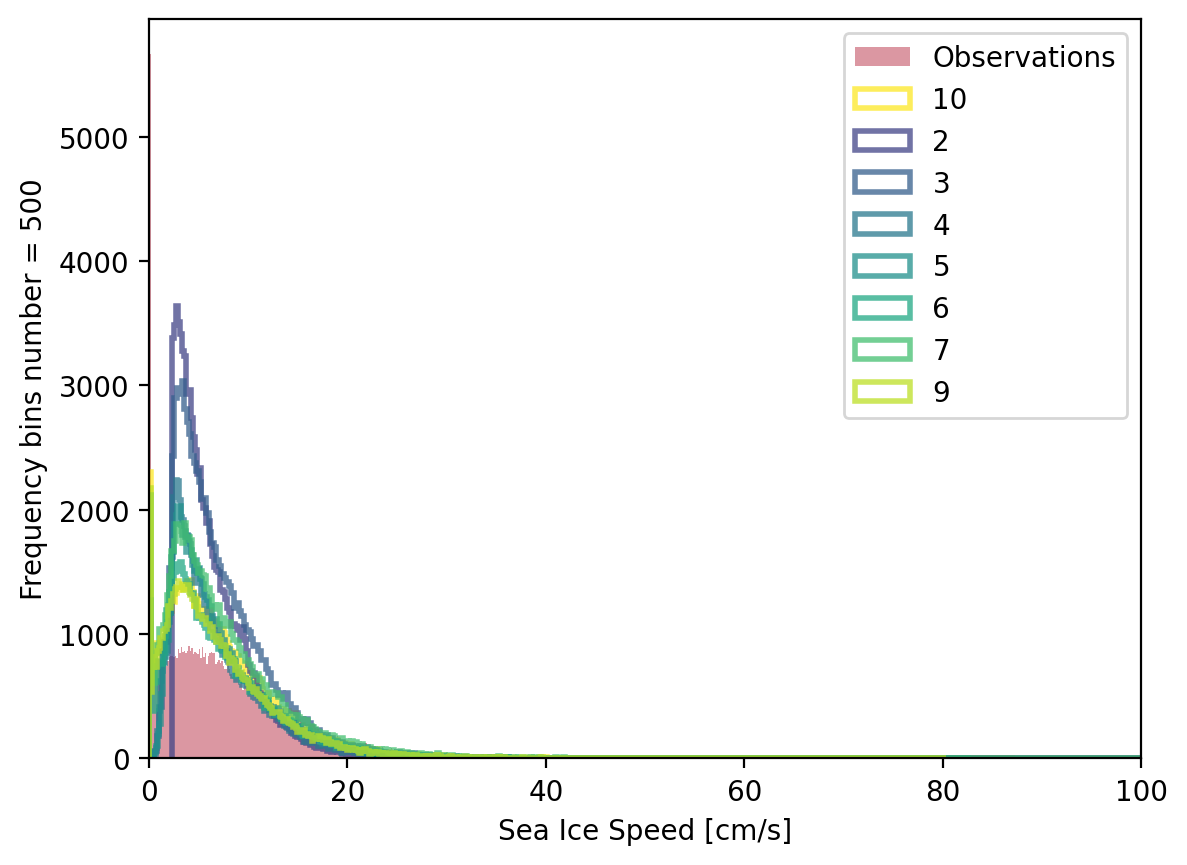

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib as mpl
fig,ax=plt.subplots(dpi=200)
norm=Normalize(0,10)
n_bins=500
cmap = mpl.colormaps['viridis']

ax.hist(data['buoynorm'],n_bins,histtype='bar', color="#BA364C84", label='Observations')
for model in inputstoweight.keys():
    #print(model[:2].strip('i'))
    number=int(model[:2].strip('i'))/10
    c=cmap(number)
    ax.hist(data[model],n_bins, color=c, histtype='step', alpha=.75,linewidth = 2 ,  label = int(number*10))
    print(inputstoweight[model])

# plt.legend()
ax.set_xlim([0,100])
ax.set_ylabel(f'Frequency bins number = {n_bins}')
ax.set_xlabel('Sea Ice Speed [cm/s]')
ax.legend()
plt.show()


{'10inputs': np.float64(4.577619046433744), '2inputs': np.float64(6.495467626338708), '3inputs': np.float64(5.854516929761035), '4inputs': np.float64(5.880973504548352), '5inputs': np.float64(5.6820928939745174), '6inputs': np.float64(5.078587705972849), '7inputs': np.float64(4.838426730541664), '9inputs': np.float64(4.773467711593792)}


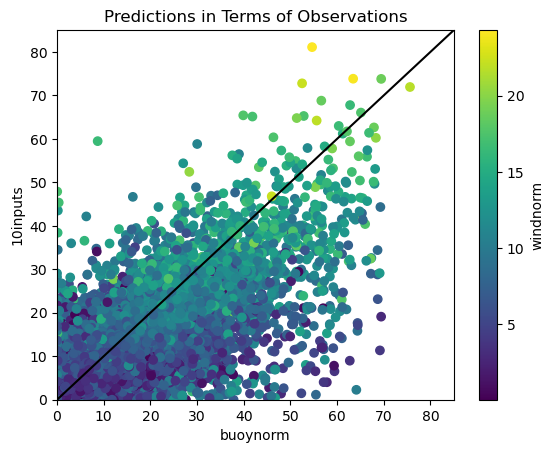

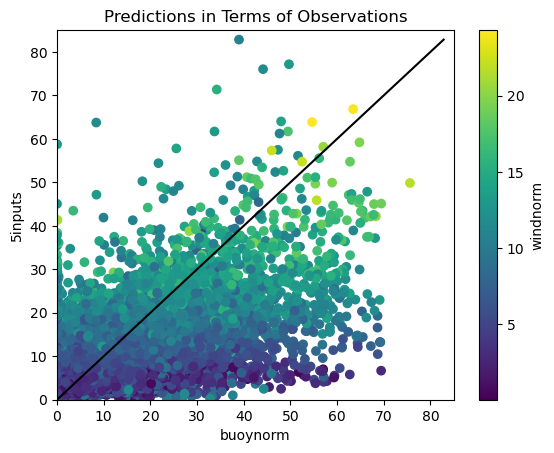

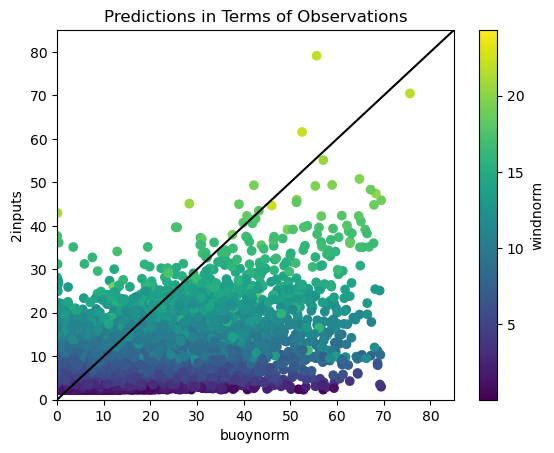

10


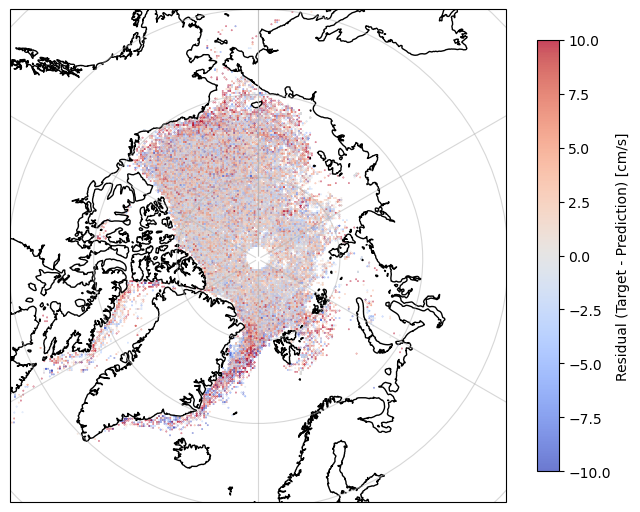

9


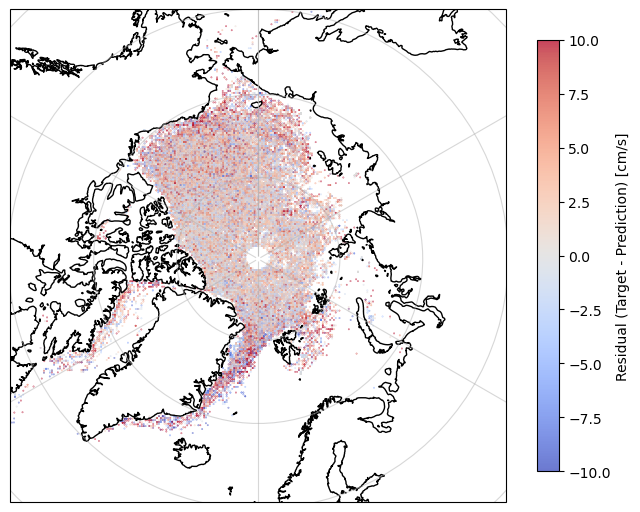

7


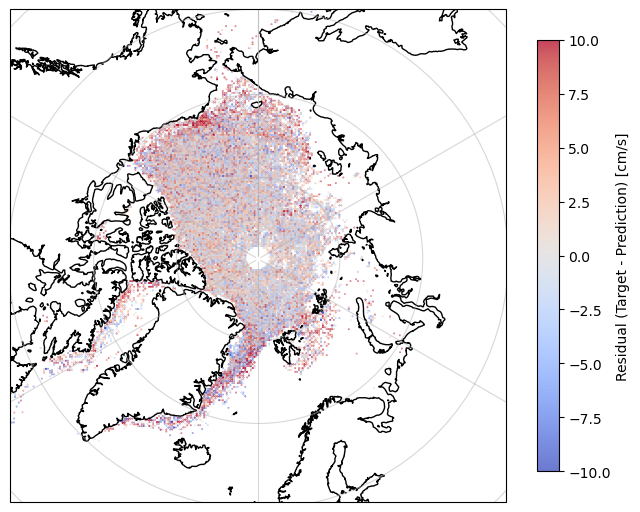

6


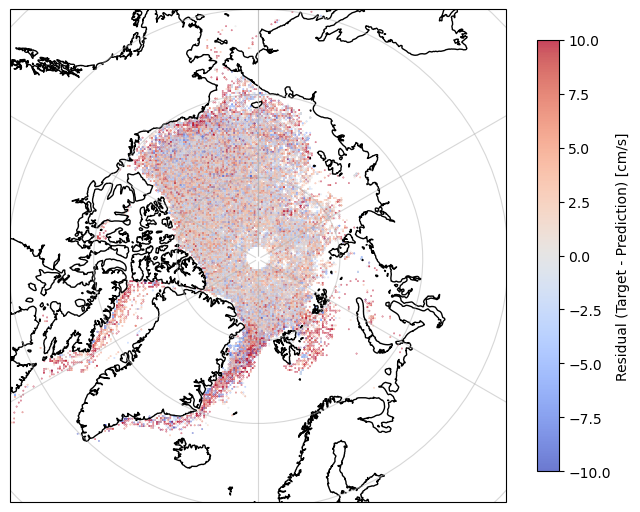

5


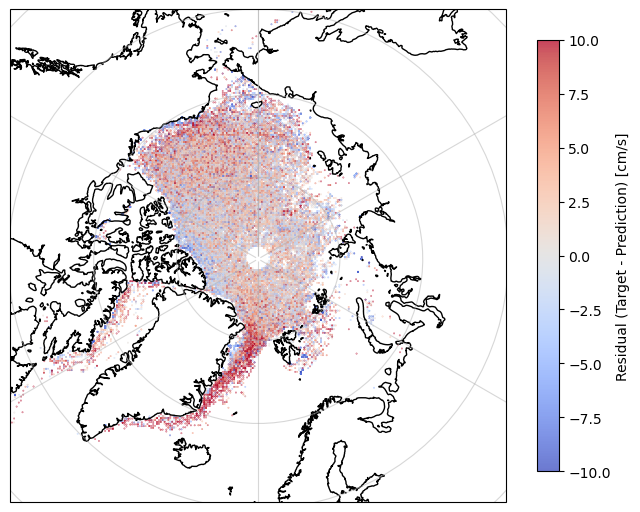

4


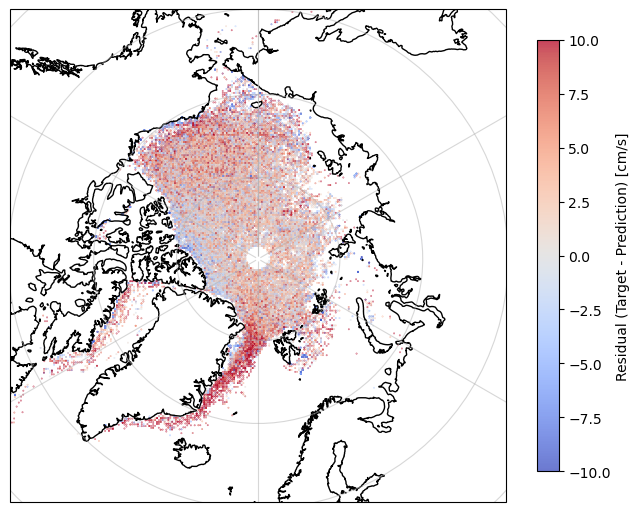

3


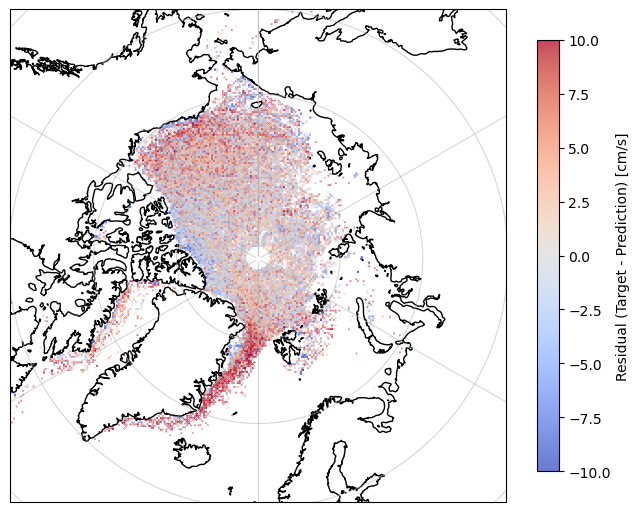

2


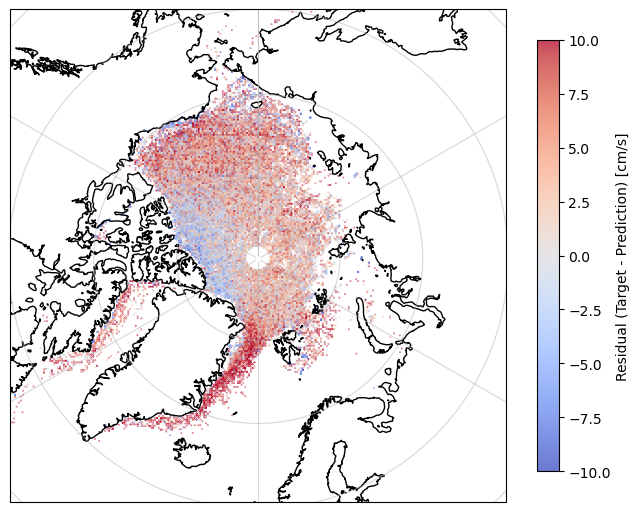

In [4]:
from AIce.plotting import PredAgainstTarget,ResidualOnTheMap,histogrammeur
print(rmse)
PredAgainstTarget(data['buoynorm'],data['10inputs'],data['windnorm'], lim=[0,85])
PredAgainstTarget(data['buoynorm'],data['5inputs'],data['windnorm'], lim=[0,85])
PredAgainstTarget(data['buoynorm'],data['2inputs'],data['windnorm'], lim=[0,85])
print(10)
ResidualOnTheMap(data, '10inputs','buoynorm',vmin=-10,vmax=10)
print(9)
ResidualOnTheMap(data,'9inputs','buoynorm',vmin=-10,vmax=10)
print(7)
ResidualOnTheMap(data, '7inputs','buoynorm',vmin=-10,vmax=10)
print(6)
ResidualOnTheMap(data,'6inputs','buoynorm',vmin=-10,vmax=10)
print(5)
ResidualOnTheMap(data, '5inputs','buoynorm',vmin=-10,vmax=10)
print(4)
ResidualOnTheMap(data,'4inputs','buoynorm',vmin=-10,vmax=10)
print(3)
ResidualOnTheMap(data, '3inputs','buoynorm',vmin=-10,vmax=10)
print(2)
ResidualOnTheMap(data,'2inputs','buoynorm',vmin=-10,vmax=10)

